# Multi-Fidelity GP Tutorial

Multi-fidelity modeling combines cheap approximate simulations with expensive accurate ones. The Kennedy-O'Hagan model:

8113f_{hi}(x) = ho \cdot f_{lo}(x) + \delta(x)8113

where ρ is a learnable correlation and δ captures the discrepancy. By leveraging many low-fidelity observations, we get tighter high-fidelity predictions with fewer expensive evaluations.

**Use case:** 10,000 coarse-mesh CFD + 50 fine-mesh runs → accurate predictions with honest uncertainty.

# Multi-Fidelity Gaussian Process

Combine cheap low-fidelity and expensive high-fidelity data.

## Interpreting the Predictions

High-fidelity predictions have tighter confidence intervals near observed high-fidelity points because the discrepancy GP has low posterior variance there. Far from high-fidelity observations, uncertainty grows — but the low-fidelity trend still anchors the mean, preventing wild extrapolation.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.models.gp.multifidelity import MultiFidelityGP

## Generate Multi-Fidelity Data

In [2]:
# True function
def f_true(x):
    return np.sin(2 * x)

# Low-fidelity: biased approximation (50 points)
np.random.seed(42)
X_lo = np.linspace(0, 2 * np.pi, 50).reshape(-1, 1)
y_lo = np.sin(2 * X_lo) + 0.5 * np.cos(X_lo) + np.random.randn(*X_lo.shape) * 0.05

# High-fidelity: accurate but expensive (10 points)
X_hi = np.linspace(0.5, 5.5, 10).reshape(-1, 1)
y_hi = f_true(X_hi) + np.random.randn(*X_hi.shape) * 0.01

# Convert to tensors
X_lo_t = torch.from_numpy(X_lo.astype(np.float32))
y_lo_t = torch.from_numpy(y_lo.astype(np.float32).ravel())
X_hi_t = torch.from_numpy(X_hi.astype(np.float32))
y_hi_t = torch.from_numpy(y_hi.astype(np.float32).ravel())

print(f"Low-fidelity data: {X_lo.shape[0]} points")
print(f"High-fidelity data: {X_hi.shape[0]} points")

Low-fidelity data: 50 points
High-fidelity data: 10 points


## Fit Multi-Fidelity GP

## Two-Stage Fitting

The multi-fidelity GP is fit in two stages: first, a GP is trained on the abundant low-fidelity data to learn the coarse trend. Then a second GP is fit to the residual (high-fidelity minus scaled low-fidelity predictions), capturing the discrepancy δ(x). This decomposition lets us exploit cheap data efficiently.

In [3]:
# Create and fit Multi-Fidelity GP
model = MultiFidelityGP()
model.optimize(X_lo_t, y_lo_t, X_hi_t, y_hi_t, n_iter=100)

[9.316855430603027,
 9.105009078979492,
 8.906993865966797,
 8.722434043884277,
 8.550949096679688,
 8.392017364501953,
 8.244877815246582,
 8.108606338500977,
 7.981986045837402,
 7.863672256469727,
 7.752248764038086,
 7.6463775634765625,
 7.54494571685791,
 7.446928977966309,
 7.351434707641602,
 7.257784843444824,
 7.16536808013916,
 7.0737810134887695,
 6.982667922973633,
 6.891852378845215,
 6.801143646240234,
 6.710501670837402,
 6.620058059692383,
 6.530084609985352,
 6.440906524658203,
 6.352974891662598,
 6.266605377197266,
 6.182056427001953,
 6.099373817443848,
 6.018567085266113,
 5.939706802368164,
 5.862804412841797,
 5.787993431091309,
 5.715312957763672,
 5.644697189331055,
 5.5758466720581055,
 5.508526802062988,
 5.442586898803711,
 5.378040313720703,
 5.314902305603027,
 5.2530670166015625,
 5.192399978637695,
 5.132772445678711,
 5.074319839477539,
 5.017163276672363,
 4.961353302001953,
 4.906830787658691,
 4.853567123413086,
 4.801705360412598,
 4.751346588134766

## Predict

In [4]:
# Test points
X_test = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
X_test_t = torch.from_numpy(X_test.astype(np.float32))

# Predict with uncertainty for both fidelities (returns UQResult)
result_lo = model.predict_uq(X_test_t, fidelity="low")
result_hi = model.predict_uq(X_test_t, fidelity="high")

mean_lo = result_lo.mean.detach().numpy()
std_lo = result_lo.epistemic_var.sqrt().detach().numpy()
mean_hi = result_hi.mean.detach().numpy()
std_hi = result_hi.epistemic_var.sqrt().detach().numpy()

print(f"High-fidelity mean std: {std_hi.mean():.4f}")
print(f"Low-fidelity mean std: {std_lo.mean():.4f}")

High-fidelity mean std: 0.1462
Low-fidelity mean std: 0.1262


## Visualize

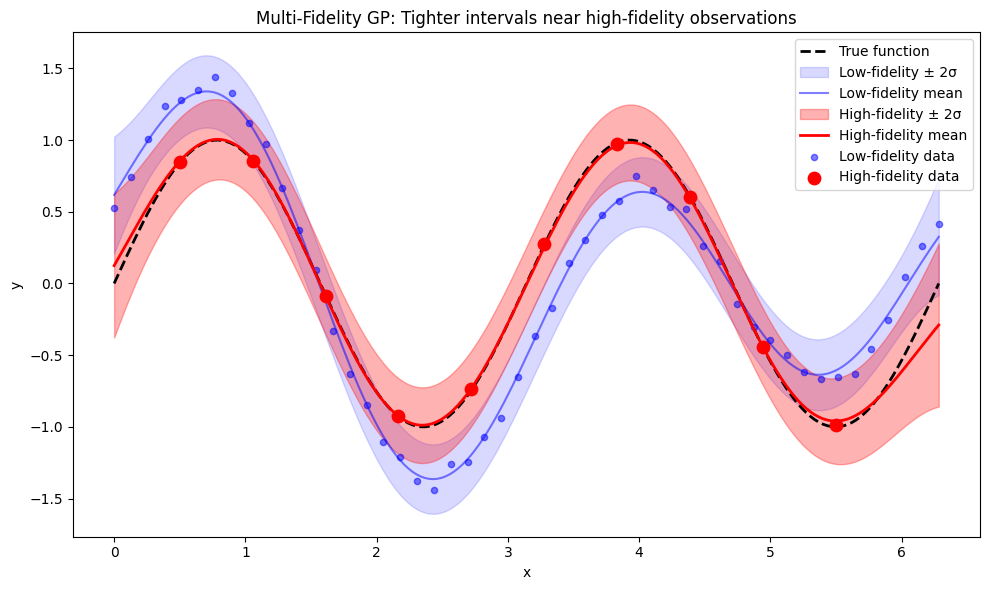

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# True function
ax.plot(X_test.ravel(), f_true(X_test).ravel(), "k--", label="True function", linewidth=2)

# Low-fidelity GP
ax.fill_between(X_test.ravel(), (mean_lo - 2*std_lo).ravel(), (mean_lo + 2*std_lo).ravel(),
                alpha=0.15, color="blue", label="Low-fidelity \u00b1 2\u03c3")
ax.plot(X_test.ravel(), mean_lo.ravel(), "b-", alpha=0.5, label="Low-fidelity mean")

# High-fidelity GP
ax.fill_between(X_test.ravel(), (mean_hi - 2*std_hi).ravel(), (mean_hi + 2*std_hi).ravel(),
                alpha=0.3, color="red", label="High-fidelity \u00b1 2\u03c3")
ax.plot(X_test.ravel(), mean_hi.ravel(), "r-", linewidth=2, label="High-fidelity mean")

# Data points
ax.scatter(X_lo.ravel(), y_lo.ravel(), c="blue", s=20, alpha=0.5, label="Low-fidelity data")
ax.scatter(X_hi.ravel(), y_hi.ravel(), c="red", s=80, zorder=5, label="High-fidelity data")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Multi-Fidelity GP: Tighter intervals near high-fidelity observations")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()